<a href="https://colab.research.google.com/github/jackpang-ltp/MathModeling/blob/main/IMMC_optimization_lab_tsp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install Gurobi's Python package in Google Colab
%pip install -q gurobipy

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp   # Create models, variables, constraints and expressions...
from gurobipy import GRB   # Specify variable type, direction,and solving status...

n_cities = 20
rng = np.random.default_rng(42)
coordinates = rng.uniform(0, 100, size=(n_cities, 2))

# Euclidean distance matrix
distance = np.linalg.norm(
    coordinates[:, None, :] - coordinates[None, :, :], axis=2
)

print("City coordinates:")
for city, (x_coord, y_coord) in enumerate(coordinates):
    print(f"City {city:2d}: ({x_coord:6.2f}, {y_coord:6.2f})")

City coordinates:
City  0: ( 77.40,  43.89)
City  1: ( 85.86,  69.74)
City  2: (  9.42,  97.56)
City  3: ( 76.11,  78.61)
City  4: ( 12.81,  45.04)
City  5: ( 37.08,  92.68)
City  6: ( 64.39,  82.28)
City  7: ( 44.34,  22.72)
City  8: ( 55.46,   6.38)
City  9: ( 82.76,  63.17)
City 10: ( 75.81,  35.45)
City 11: ( 97.07,  89.31)
City 12: ( 77.84,  19.46)
City 13: ( 46.67,   4.38)
City 14: ( 15.43,  68.30)
City 15: ( 74.48,  96.75)
City 16: ( 32.58,  37.05)
City 17: ( 46.96,  18.95)
City 18: ( 12.99,  47.57)
City 19: ( 22.69,  66.98)


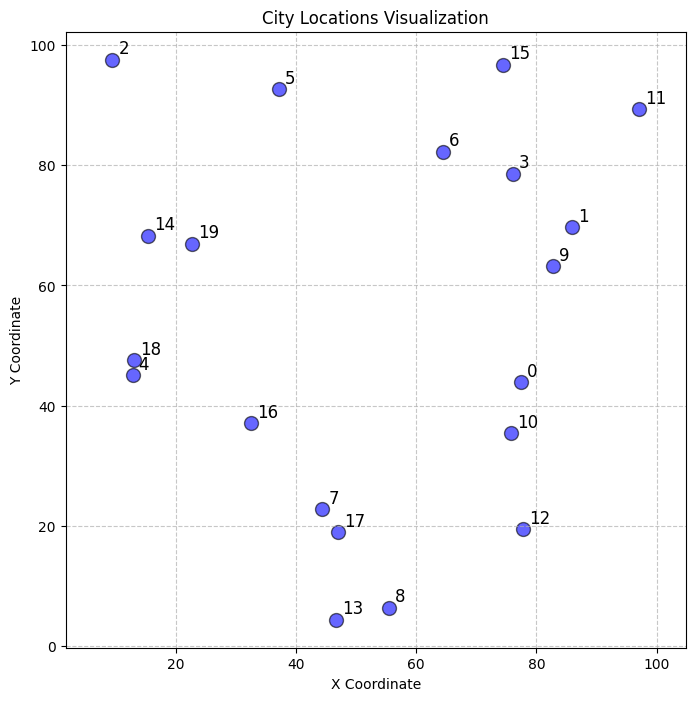

In [ ]:


plt.figure(figsize=(8, 8))
plt.scatter(coordinates[:, 0], coordinates[:, 1], s=100, color='blue', alpha=0.6, edgecolors='black')


for i, (x, y) in enumerate(coordinates):
    plt.text(x + 1, y + 1, str(i), fontsize=12)

plt.title("City Locations Visualization")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.show()

In [6]:
# Create model
model = gp.Model("TSP")

cities = range(n_cities)
arcs = [(i, j) for i in cities for j in cities if i != j]

# x[i, j] = 1 if the tour goes directly from i to j
x = model.addVars(arcs, vtype=GRB.BINARY, name="x")

# Visit-order variables for all cities except depot 0
u = model.addVars(
    range(1, n_cities), lb=1, ub=n_cities - 1, name="u"
)

# Minimize total travel distance
model.setObjective(
    gp.quicksum(distance[i, j] * x[i, j] for i, j in arcs),
    GRB.MINIMIZE,
)

# Exactly one departure from and one arrival at each city
model.addConstrs(
    (gp.quicksum(x[i, j] for j in cities if j != i) == 1 for i in cities),
    name="leave",
)
model.addConstrs(
    (gp.quicksum(x[i, j] for i in cities if i != j) == 1 for j in cities),
    name="enter",
)

# Miller-Tucker-Zemlin constraints eliminate subtours
model.addConstrs(
    (
        u[i] - u[j] + n_cities * x[i, j] <= n_cities - 1
        for i in range(1, n_cities)
        for j in range(1, n_cities)
        if i != j
    ),
    name="mtz",
)

model.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 382 rows, 399 columns and 1786 nonzeros (Min)
Model fingerprint: 0x40b1caa9
Model has 380 linear objective coefficients
Variable types: 19 continuous, 380 integer (380 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [3e+00, 1e+02]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 2e+01]

Presolve time: 0.01s
Presolved: 382 rows, 399 columns, 1786 nonzeros
Variable types: 19 continuous, 380 integer (380 binary)
Found heuristic solution: objective 1003.2299327

Root relaxation: objective 2.816010e+02, 75 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work


In [7]:
if model.Status != GRB.OPTIMAL:
    raise RuntimeError("Gurobi did not find an optimal solution.")

# Reconstruct the tour, starting from depot 0
selected_arcs = [(i, j) for (i, j), var in x.items() if var.X > 0.5]
successor = {i: j for i, j in selected_arcs}

tour = [0]
while len(tour) < n_cities:
    tour.append(successor[tour[-1]])
tour.append(0)

print("Optimal tour:", " -> ".join(map(str, tour)))
print(f"Minimum total distance: {model.ObjVal:.2f}")


Optimal tour: 0 -> 10 -> 12 -> 8 -> 13 -> 17 -> 7 -> 16 -> 4 -> 18 -> 19 -> 14 -> 2 -> 5 -> 6 -> 3 -> 15 -> 11 -> 1 -> 9 -> 0
Minimum total distance: 341.58


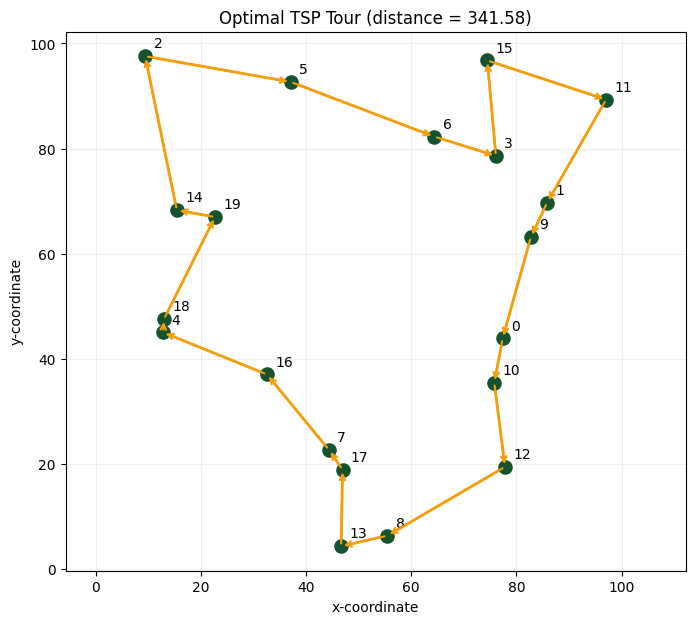

In [8]:

# Plot cities and the optimal tour
route_points = coordinates[tour]
plt.figure(figsize=(8, 7))
plt.scatter(coordinates[:, 0], coordinates[:, 1], s=90, color="#14532d", zorder=3)
plt.plot(route_points[:, 0], route_points[:, 1], color="#f59e0b", linewidth=2, zorder=2)

for city, (x_coord, y_coord) in enumerate(coordinates):
    plt.annotate(str(city), (x_coord, y_coord), xytext=(6, 6), textcoords="offset points")

for start, end in zip(route_points[:-1], route_points[1:]):
    plt.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", color="#f59e0b", lw=1.5),
    )

plt.title(f"Optimal TSP Tour (distance = {model.ObjVal:.2f})")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(alpha=0.2)
plt.axis("equal")
plt.show()

In [9]:
# @title 🚚 TSP Optimal Tour Dashboard {display-mode: "form"}

import json
import numpy as np
from IPython.display import HTML
from google.colab import output

# Helper for debugging JS errors
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Prepare Data
# We use the existing 'coordinates', 'tour', and 'model.ObjVal' from the kernel
tour_coords = coordinates[tour].tolist()
all_cities = coordinates.tolist()
total_dist = float(model.ObjVal)
avg_dist = float(np.mean(distance[distance > 0]))

dashboard_data = {
    'tour_coords': tour_coords,
    'all_cities': all_cities,
    'tour_indices': tour,
    'total_dist': round(total_dist, 2),
    'num_cities': len(all_cities),
    'avg_edge': round(avg_dist, 2)
}

html_content = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; }
        .container { display: grid; grid-template-columns: repeat(4, 1fr); grid-gap: 20px; }
        .card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center; }
        .kpi-val { font-size: 24px; font-weight: bold; color: #14532d; }
        .kpi-label { color: #666; font-size: 14px; margin-top: 5px; }
        .wide-card { grid-column: span 3; background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }
        .side-card { grid-column: span 1; background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 400px; }
        h3 { margin-top: 0; color: #333; }
        .table-container { height: 350px; overflow-y: auto; }
        table { width: 100%; border-collapse: collapse; font-size: 13px; }
        th, td { padding: 10px; border-bottom: 1px solid #eee; text-align: left; }
        th { position: sticky; top: 0; background: #fff; }
    </style>
</head>
<body>
    <div class="container">
        <div class="card"><div class="kpi-val">JSON_DATA.num_cities</div><div class="kpi-label">Total Cities</div></div>
        <div class="card"><div class="kpi-val">JSON_DATA.total_dist</div><div class="kpi-label">Total Distance</div></div>
        <div class="card"><div class="kpi-val">JSON_DATA.avg_edge</div><div class="kpi-label">Avg. Distance (All Pairs)</div></div>
        <div class="card"><div class="kpi-val">#14532d</div><div class="kpi-label">Status: Optimal</div></div>

        <div class="wide-card">
            <h3>Optimal Route Visualization</h3>
            <div class="canvas-wrapper">
                <canvas id="tspChart"></canvas>
            </div>
        </div>

        <div class="side-card">
            <h3>City Coordinates</h3>
            <div class="table-container">
                <table id="cityTable"><thead><tr><th>ID</th><th>X</th><th>Y</th></tr></thead><tbody></tbody></table>
            </div>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const data = DATA_PLACEHOLDER;

        // Populate Table
        const tbody = document.querySelector('#cityTable tbody');
        data.all_cities.forEach((coords, i) => {
            const row = tbody.insertRow();
            row.insertCell(0).innerText = i;
            row.insertCell(1).innerText = coords[0].toFixed(2);
            row.insertCell(2).innerText = coords[1].toFixed(2);
        });

        // Chart.js Setup
        const ctx = document.getElementById('tspChart').getContext('2d');
        const tourPoints = data.tour_coords.map(p => ({x: p[0], y: p[1]}));
        const allPoints = data.all_cities.map((p, i) => ({x: p[0], y: p[1], id: i}));

        new Chart(ctx, {
            type: 'scatter',
            data: {
                datasets: [{
                    label: 'Optimal Tour',
                    data: tourPoints,
                    showLine: true,
                    borderColor: '#f59e0b',
                    borderWidth: 3,
                    pointRadius: 0,
                    fill: false,
                    tension: 0
                }, {
                    label: 'Cities',
                    data: allPoints,
                    backgroundColor: '#14532d',
                    pointRadius: 6,
                    pointHoverRadius: 8
                }]
            },
            options: {
                responsive: true,
                maintainAspectRatio: false,
                scales: {
                    x: { grid: { color: '#eee' }, title: { display: true, text: 'X coordinate' } },
                    y: { grid: { color: '#eee' }, title: { display: true, text: 'Y coordinate' } }
                },
                plugins: {
                    tooltip: {
                        callbacks: {
                            label: (ctx) => ctx.raw.id !== undefined ? `City ${ctx.raw.id}: (${ctx.raw.x.toFixed(2)}, ${ctx.raw.y.toFixed(2)})` : `Step ${ctx.dataIndex}`
                        }
                    }
                }
            }
        });
    </script>
</body>
</html>
"""

# Inject data safely
final_html = html_content.replace('DATA_PLACEHOLDER', json.dumps(dashboard_data))
final_html = final_html.replace('JSON_DATA.num_cities', str(dashboard_data['num_cities']))
final_html = final_html.replace('JSON_DATA.total_dist', str(dashboard_data['total_dist']))
final_html = final_html.replace('JSON_DATA.avg_edge', str(dashboard_data['avg_edge']))

display(HTML(final_html))

ID,X,Y
